## <span style="color:#2F749F;"><strong>📦 Sesión práctica 2: Análisis Univariado, bivariado y multivariado</strong></span>


## <span style="color:black;"><strong>Datos de los estudiantes</strong></span>

In [ ]:
nombre = input("📝 Ingresa el nombre completo del integrante 1: ")
correo = input("📧 Ingresa el correo electrónico del integrante 1: ")
cedula = input("🔢 Ingresa los últimos 6 dígitos de la cédula del integrante 1: ")

nombre2 = input("📝 Ingresa el nombre completo del integrante 2: ")
correo2 = input("📧 Ingresa el correo electrónico del integrante 2: ")
cedula2 = input("🔢 Ingresa los últimos 6 dígitos de la cédula del integrante 2: ")

📝 Ingresa el nombre completo del integrante 1: Lukas Piedrahita
📧 Ingresa el correo electrónico del integrante 1: lukas.piedrahita@udea.edu.co
🔢 Ingresa los últimos 6 dígitos de la cédula del integrante 1: 872196
📝 Ingresa el nombre completo del integrante 2: Carlos Rodríguez
📧 Ingresa el correo electrónico del integrante 2: gilberto.rodriguez@udea.edu.co
🔢 Ingresa los últimos 6 dígitos de la cédula del integrante 2: 266552


## <span style="color:black;"><strong>Parte 1: Análisis Univariado</strong></span>

### <span style="color:#2F749F;"><strong>Ejercicio 1: Cálculo de medidas de tendencia central</strong></span>

A partir de una muestra simulada de ingresos, calcula la **media, mediana y moda**, y luego a interpretarlas.

1. Usa el número base `528310` (debes reemplazarlo con los últimos 6 dígitos de tu documento de identificación).  
2. Con este número genera una semilla (`np.random.seed`) para que los resultados sean reproducibles.  
3. Los ingresos se simulan con una distribución normal:  
   - Media teórica: `(base % 10) + 2`  
   - Desviación estándar: `2`  
   - Tamaño de muestra: `30`  
4. Los valores negativos se reemplazan por cero (pues los ingresos no pueden ser negativos).  
5. Grafica tus resultados (ver imagen de ejemplo)

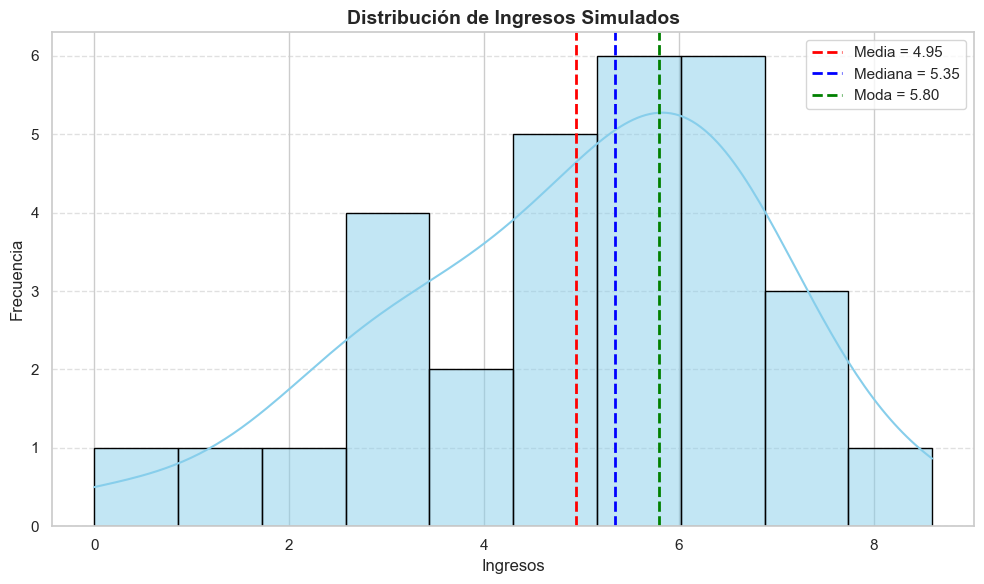

# **Solución Ejercicio 1**

In [1]:
# Descarga de la última versión
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sonalshinde123/work-from-home-employee-burnout-dataset")

print("Path to dataset files:", path)

100%|██████████| 27.3k/27.3k [00:00<00:00, 11.1MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/sonalshinde123/work-from-home-employee-burnout-dataset/versions/1


In [43]:
# Librerías
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from scipy.stats import skew, kurtosis, norm, pearsonr, spearmanr, chi2_contingency, shapiro
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Estilo general
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

In [3]:
# --- Creación del Dataset ---
files = os.listdir(path)
csv_file = [f for f in files if f.endswith('.csv')][0]
df = pd.read_csv(os.path.join(path, csv_file))

# --- Propiedades del DataSet ---

# Nombres de las columnas
print("\nColumnas:", df.columns.tolist())



Columnas: ['user_id', 'day_type', 'work_hours', 'screen_time_hours', 'meetings_count', 'breaks_taken', 'after_hours_work', 'sleep_hours', 'task_completion_rate', 'burnout_score', 'burnout_risk']


In [4]:
df

,user_id,day_type,work_hours,screen_time_hours,meetings_count,breaks_taken,after_hours_work,sleep_hours,task_completion_rate,burnout_score,burnout_risk
0,1,Weekday,9.59,11.86,4,2,0,7.55,91.2,19.17,Low
1,1,Weekend,7.38,10.33,4,1,0,6.69,82.0,29.70,Low
2,1,Weekend,6.31,8.92,1,2,0,8.87,80.6,32.93,Low
3,1,Weekday,8.34,10.70,4,1,1,8.13,70.0,45.47,Low
4,1,Weekend,6.97,9.83,1,2,0,5.85,67.1,51.61,Low
...,...,...,...,...,...,...,...,...,...,...,...
1795,180,Weekend,6.33,8.16,0,4,0,5.59,73.5,31.91,Low
1796,180,Weekend,4.70,7.88,0,4,0,6.69,89.8,26.30,Low
1797,180,Weekend,3.92,6.39,2,1,0,6.77,74.6,34.07,Low
1798,180,Weekday,8.93,11.11,2,5,0,8.28,74.6,38.14,Low


In [18]:
# Extracción de submuestra
sub_df = df.sample(frac=0.6, random_state=42)

In [19]:
#Visualización de los datos:
sub_df.head()

,user_id,day_type,work_hours,screen_time_hours,meetings_count,breaks_taken,after_hours_work,sleep_hours,task_completion_rate,burnout_score,burnout_risk
1591,160,Weekday,7.13,11.05,3,3,0,6.74,92.8,17.98,Low
943,95,Weekend,4.87,7.97,1,2,1,6.36,81.2,29.45,Low
869,87,Weekend,3.89,6.00,2,1,1,7.22,40.0,106.94,Medium
162,17,Weekday,8.83,12.00,2,1,0,6.85,84.0,25.41,Low
1271,128,Weekday,8.34,12.15,3,3,0,6.51,76.1,35.01,Low


Medidas de tendencia central:
Media:   9.35 horas de uso de pantalla
Mediana: 9.34 horas de uso de pantalla
Moda:    11.93 horas de uso de pantalla


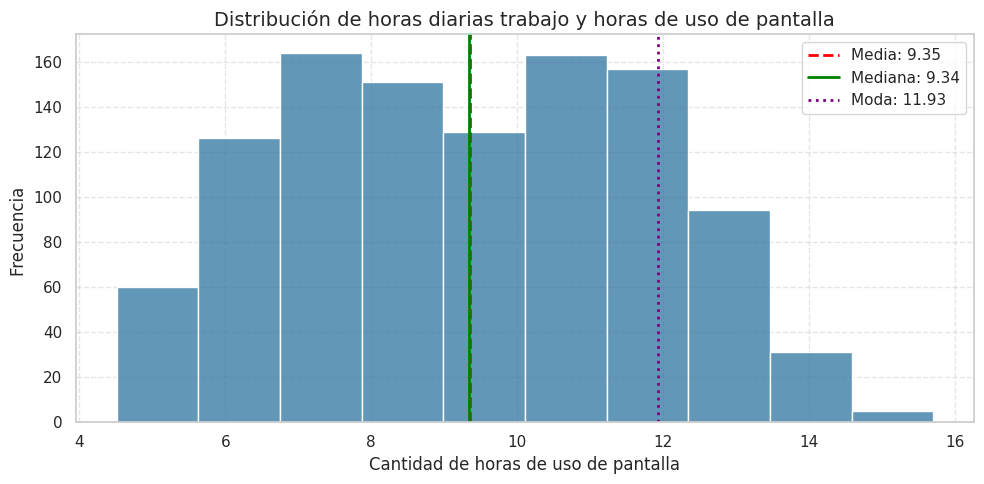

In [20]:
# Medidas de tendencia central
media = np.mean(sub_df.screen_time_hours)
mediana = np.median(sub_df.screen_time_hours)
moda = stats.mode(sub_df.screen_time_hours, keepdims=True)[0][0]

# Resultados
print("Medidas de tendencia central:")
print(f"Media:   {media:.2f} horas de uso de pantalla")
print(f"Mediana: {mediana:.2f} horas de uso de pantalla")
print(f"Moda:    {moda:.2f} horas de uso de pantalla")

plt.figure(figsize=(10, 5))
sns.histplot(sub_df.screen_time_hours, bins=10, kde=False, color="#2F749F")

# Líneas de tendencia central
plt.axvline(media, color='red', linestyle='--', linewidth=2, label=f'Media: {media:.2f}')
plt.axvline(mediana, color='green', linestyle='-', linewidth=2, label=f'Mediana: {mediana:.2f}')
plt.axvline(moda, color='purple', linestyle=':', linewidth=2, label=f'Moda: {moda:.2f}')

plt.title("Distribución de horas diarias trabajo y horas de uso de pantalla", fontsize=14)
plt.xlabel("Cantidad de horas de uso de pantalla", fontsize=12)
plt.ylabel("Frecuencia ", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### <span style="color:#2F749F;"><strong>Ejercicio 2: Cálculo de medidas de dispersión</strong></span>

A partir de la muestra generada en el Ejercicio 1, analiza qué tan dispersos están los datos respecto a su media. Calcula:
1. Rango
2. Varianza
3. Desviación estándar
4. Coeficiente de variación
5. Genera una gráfica con los resultados obtenidos (ver imagen de ejemplo)

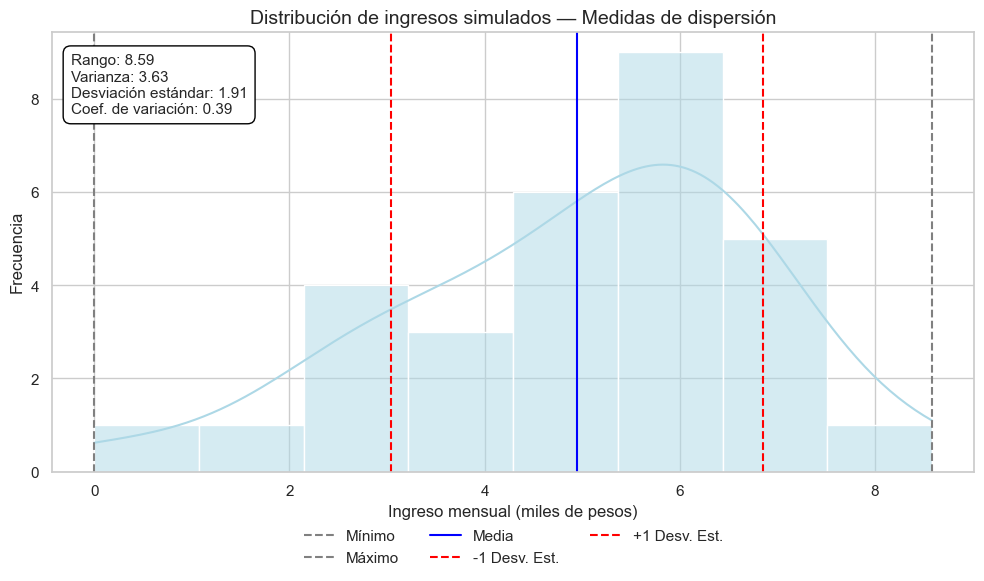

# **Solución Ejercicio 2**

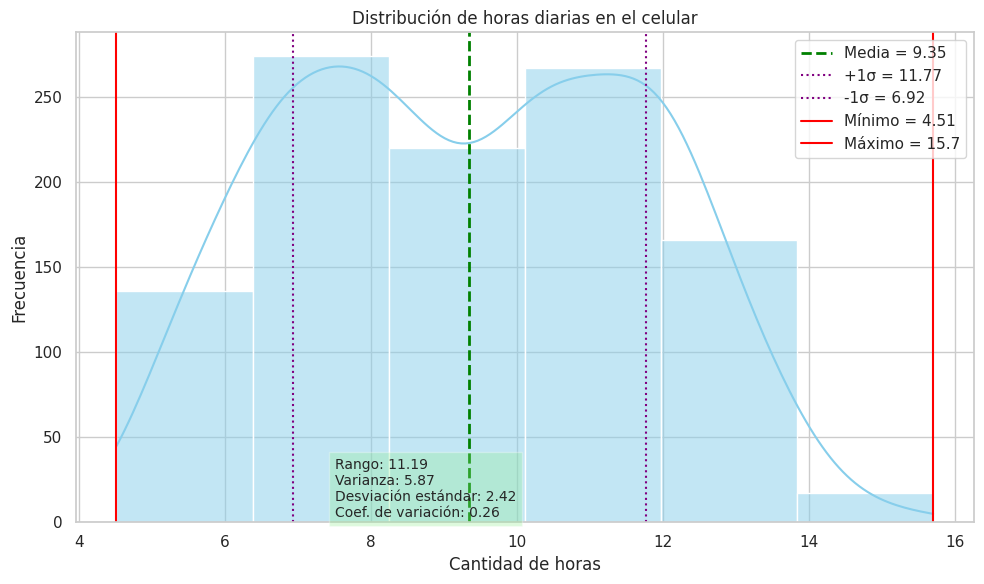

In [21]:
# Cálculo de medidas de dispersión
media = np.mean(sub_df.screen_time_hours)
minimo = np.min(sub_df.screen_time_hours)
maximo = np.max(sub_df.screen_time_hours)
rango = maximo - minimo
varianza = np.var(sub_df.screen_time_hours, ddof=1)
desviacion = np.std(sub_df.screen_time_hours, ddof=1)
coef_var = desviacion / media

# Visualización
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.histplot(sub_df.screen_time_hours, bins=6, kde=True, color='skyblue')

plt.axvline(media, color='green', linestyle='--', linewidth=2, label=f'Media = {media:.2f}')
plt.axvline(media + desviacion, color='purple', linestyle=':', linewidth=1.5, label=f'+1σ = {media + desviacion:.2f}')
plt.axvline(media - desviacion, color='purple', linestyle=':', linewidth=1.5, label=f'-1σ = {media - desviacion:.2f}')
plt.axvline(minimo, color='red', linestyle='-', linewidth=1.5, label=f'Mínimo = {minimo}')
plt.axvline(maximo, color='red', linestyle='-', linewidth=1.5, label=f'Máximo = {maximo}')

plt.title("Distribución de horas diarias en el celular")
plt.xlabel("Cantidad de horas")
plt.ylabel("Frecuencia")
plt.legend()

# Recuadro con medidas
texto = (
    f"Rango: {rango}\n"
    f"Varianza: {varianza:.2f}\n"
    f"Desviación estándar: {desviacion:.2f}\n"
    f"Coef. de variación: {coef_var:.2f}"
)
plt.text(7.5, 3, texto, bbox=dict(facecolor='lightgreen', alpha=0.3), fontsize=10)

plt.tight_layout()
plt.show()


### <span style="color:#2F749F;"><strong>Ejercicio 3: Cálculo de medidas de distribución</strong></span>

A partir de la muestra generada en el Ejercicio 1, analiza la distribución de los datos. Calcula:
1. Asimetría
2. Curtosis
3. Realiza la comparación con la distribución normal (ver la imagen de ejemplo)

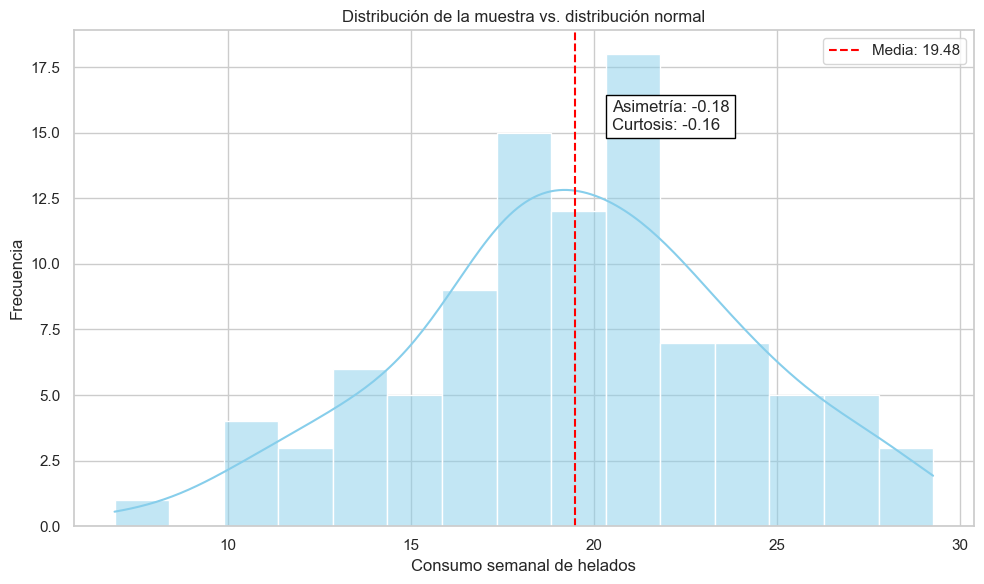


# **Solución Ejercicio 3**

In [22]:
# Calculamos los estadísticos
asimetria = skew(sub_df.screen_time_hours, bias=False)
curtosis_fischer = kurtosis(sub_df.screen_time_hours, bias=False) # Curtosis excedente

print(f"Asimetría (Skewness): {asimetria:.4f}")
print(f"Curtosis: {curtosis_fischer:.4f}")

Asimetría (Skewness): 0.0444
Curtosis: -1.0015


<Figure size 1000x600 with 0 Axes>

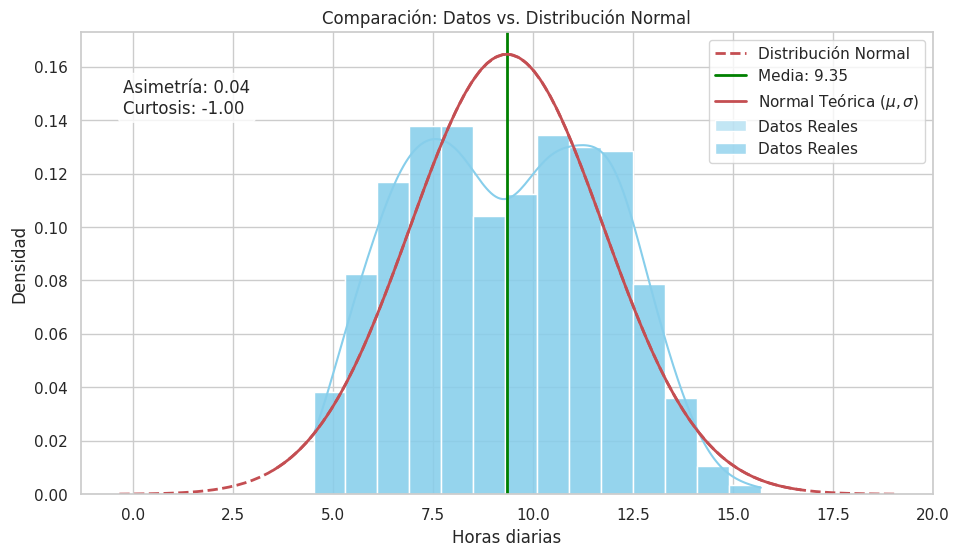

In [23]:
plt.figure(figsize=(10, 6))

# Datos
datos = sub_df.screen_time_hours.dropna()
mu, sigma = datos.mean(), datos.std()
asim = skew(datos)
curt = kurtosis(datos) # Curtosis de Fischer (Normal = 0)

# Configuración del gráfico
plt.figure(figsize=(11, 6))
sns.histplot(datos, kde=True, stat="density", color="skyblue", alpha=0.5, label="Datos Reales")

# Curva Normal de referencia
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 100)
plt.plot(x, norm.pdf(x, mu, sigma), 'r--', lw=2, label="Distribución Normal")

# Línea de la Media
plt.axvline(mu, color='green', linestyle='-', linewidth=2, label=f"Media: {mu:.2f}")

# Anotaciones de Asimetría y Curtosis
texto_info = (f"Asimetría: {asim:.2f}\n"
              f"Curtosis: {curt:.2f}")

plt.text(0.05, 0.90, texto_info, transform=plt.gca().transAxes, fontsize=12,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))


# Histograma de tus datos (Normalizado con density=True)
sns.histplot(sub_df.screen_time_hours, kde=False, stat="density", color="skyblue", label="Datos Reales")

# Generamos la curva de la Distribución Normal teórica
x = np.linspace(minimo - 1, maximo + 1, 100)
p = norm.pdf(x, media, desviacion)

plt.plot(x, p, 'r', linewidth=2, label='Normal Teórica ($\\mu, \\sigma$)')

# Detalles finales
plt.title("Comparación: Datos vs. Distribución Normal")
plt.xlabel("Horas diarias")
plt.ylabel("Densidad")
plt.legend()
plt.show()

### <span style="color:#2F749F;"><strong>Ejercicio 4: Cálculo de medidas de percentiles</strong></span>

A partir de la muestra generada en el Ejercicio 1, calcula los percentiles de tus datos. Calcula:
1. Percentiles
2. Deciles
3. Cuartiles
4. Grafica los anteriores percentiles calculados, sobre la distribución de tus datos (ver la imagen de ejemplo)

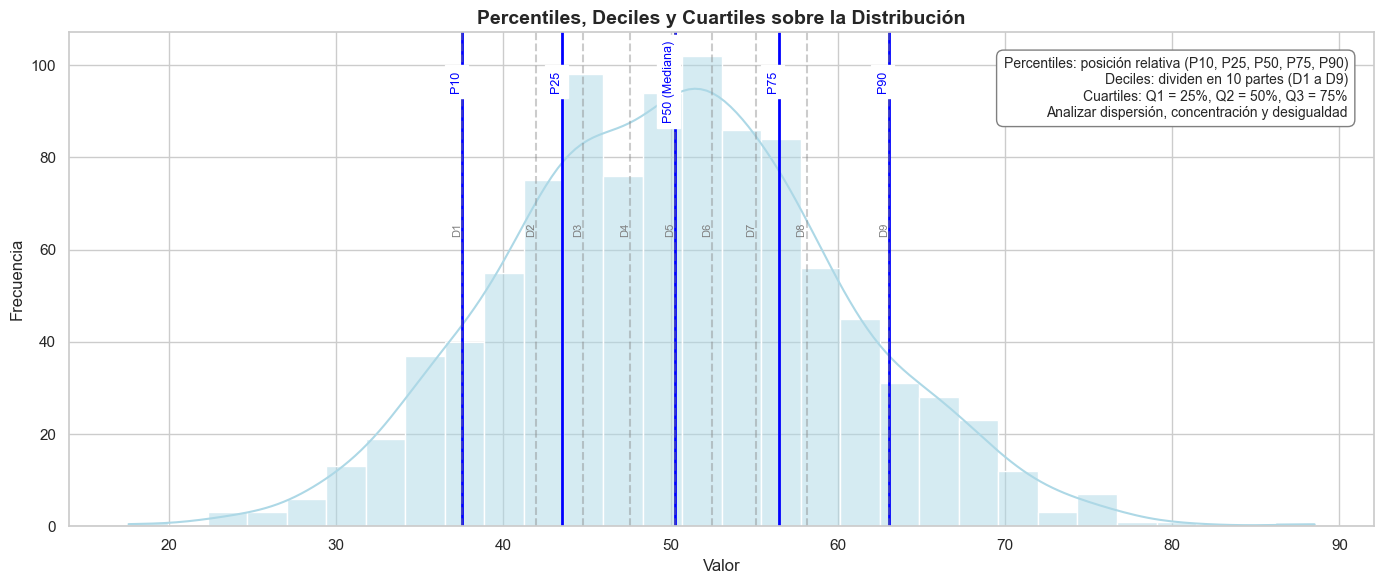

# **Solución Ejercicio 4**

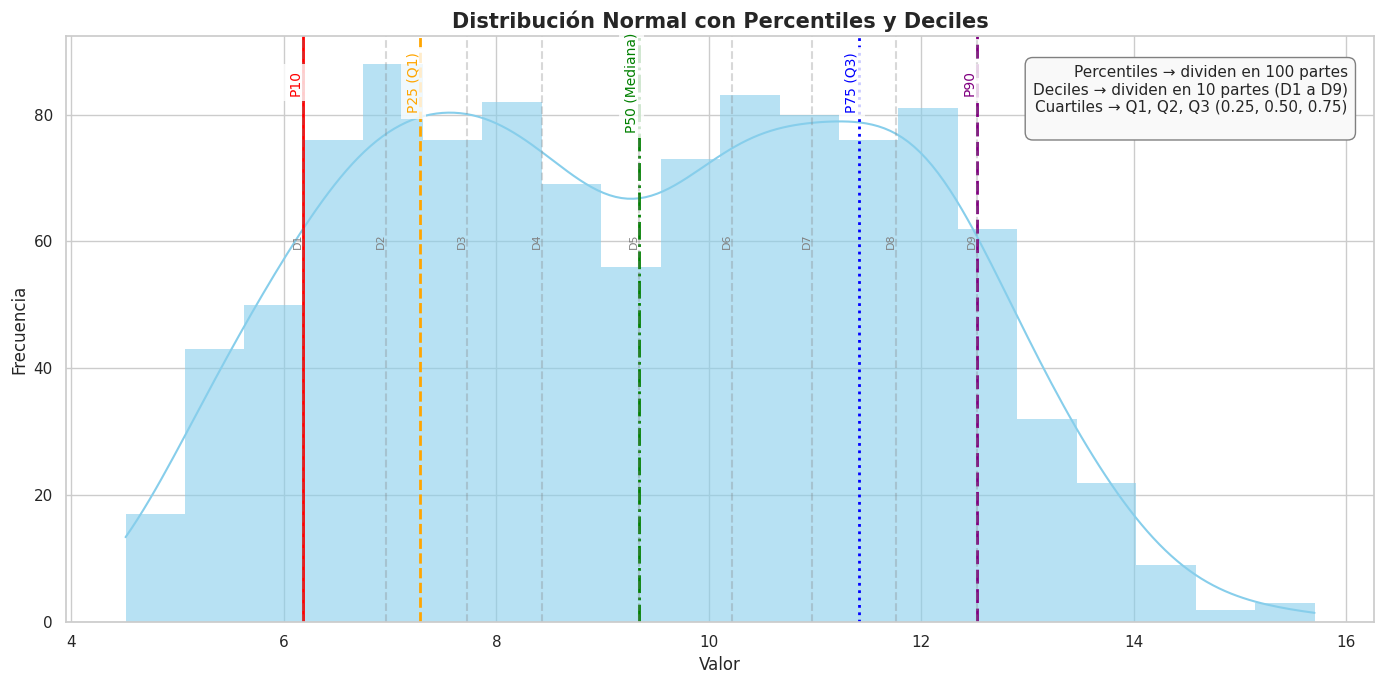

In [25]:
# Cálculo de percentiles clave
percentiles = {
    'P10': {'valor': np.percentile(sub_df.screen_time_hours, 10), 'color': 'red', 'linestyle': '-'},
    'P25 (Q1)': {'valor': np.percentile(sub_df.screen_time_hours, 25), 'color': 'orange', 'linestyle': '--'},
    'P50 (Mediana)': {'valor': np.percentile(sub_df.screen_time_hours, 50), 'color': 'green', 'linestyle': '-.'},
    'P75 (Q3)': {'valor': np.percentile(sub_df.screen_time_hours, 75), 'color': 'blue', 'linestyle': ':'},
    'P90': {'valor': np.percentile(sub_df.screen_time_hours, 90), 'color': 'purple', 'linestyle': (0, (5, 2))}
}

# Cálculo de deciles (D1 a D9)
deciles = {f'D{i}': np.percentile(sub_df.screen_time_hours, i * 10) for i in range(1, 10)}

# Visualización
plt.figure(figsize=(14, 7))
sns.histplot(sub_df.screen_time_hours, kde=True, color='skyblue', bins=20, edgecolor="None", alpha=0.6)

# Líneas verticales de percentiles
for etiqueta, props in percentiles.items():
    plt.axvline(props['valor'], color=props['color'], linestyle=props['linestyle'], linewidth=2)
    plt.text(props['valor'], plt.ylim()[1]*0.92, etiqueta,
             rotation=90, color=props['color'], fontsize=10,
             verticalalignment='center', horizontalalignment='right',
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

# Líneas verticales de deciles
for etiqueta, valor in deciles.items():
    plt.axvline(valor, color='gray', linestyle='--', alpha=0.3)
    plt.text(valor, plt.ylim()[1]*0.65, etiqueta,
             rotation=90, color='gray', fontsize=8,
             verticalalignment='center', horizontalalignment='right')

texto = (
    "Percentiles → dividen en 100 partes\n"
    "Deciles → dividen en 10 partes (D1 a D9)\n"
    "Cuartiles → Q1, Q2, Q3 (0.25, 0.50, 0.75)\n")
plt.text(0.98, 0.95, texto, transform=plt.gca().transAxes,
         fontsize=11, verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle="round,pad=0.5", facecolor="#f9f9f9", edgecolor="gray"))

plt.title("Distribución Normal con Percentiles y Deciles", fontsize=15, fontweight='bold')
plt.xlabel("Valor")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

## <span style="color:black;"><strong>Parte 2: Análisis Bivariado</strong></span>

### <span style="color:#2F749F;"><strong>Ejercicio 5: Análisis de correlación</strong></span>

En esta segunda parte, genera **dos variables** a partir de tú número de cédula y realiza un análisis **bivariado** para calcular la relación entre ellas.

1. Use los **6 últimos dígitos** de su cédula como base (similar al Ejercicio 1).  
2. Genere dos variables aleatorias (ejemplo: `ingresos` y `gastos`) con distribución normal, usando esa base como **semilla reproducible**.  
3. Calcule los coeficientes de correlación de **Pearson** y **Spearman**.
4. Grafique las variables analizadas (ver la imagen de ejemplo)
5. Interprete los resultados.  

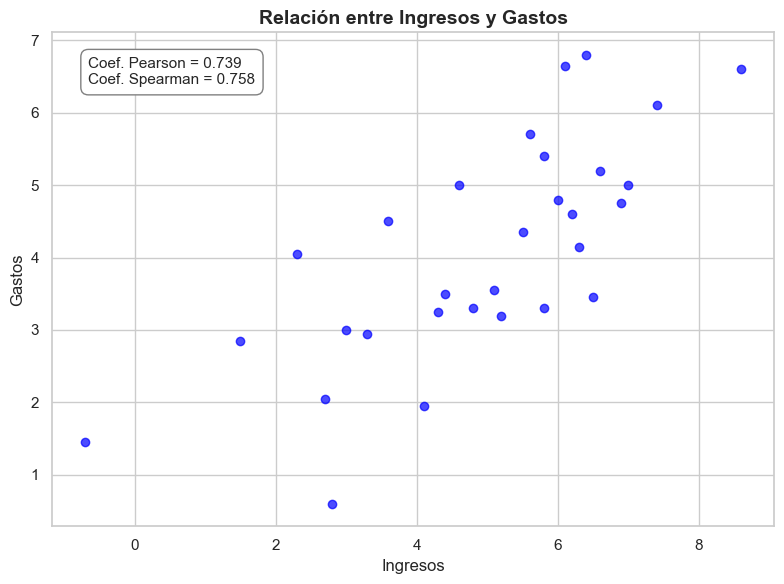

# Solución Ejercicio 5

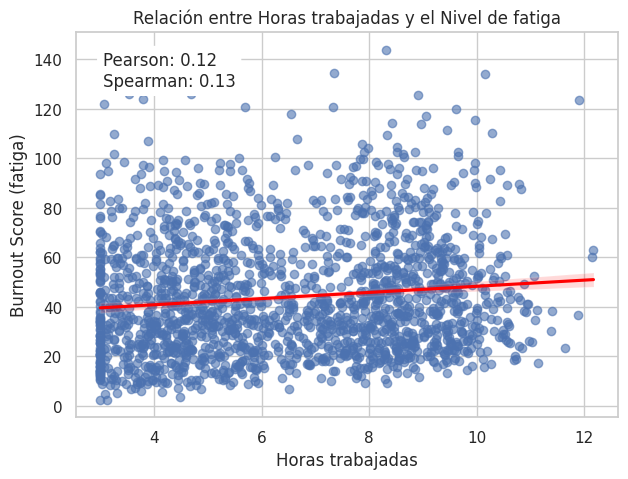

In [26]:
x = df['work_hours']
y = df['burnout_score']

# Calcular correlaciones
pearson_corr, _ = pearsonr(x, y)
spearman_corr, _ = spearmanr(x, y)

plt.figure(figsize=(7,5))
sns.regplot(
    x=x,
    y=y,
    scatter_kws={'alpha':0.6},
    line_kws={'color':'red'}
)

plt.title("Relación entre Horas trabajadas y el Nivel de fatiga")
plt.text(
    0.05, 0.95,
    f"Pearson: {pearson_corr:.2f}\nSpearman: {spearman_corr:.2f}",
    transform=plt.gca().transAxes,
    verticalalignment='top',
    bbox=dict(boxstyle="round", facecolor="white")
)

plt.xlabel("Horas trabajadas")
plt.ylabel("Burnout Score (fatiga)")

plt.show()

### Interpretación

Con unos valores de Pearson y Spearman similares y tan bajos (0.12 y 0.13 respectivamente), se puede decir que la relación lineal existente entre las horas trabajadas y el nivel de fatiga es existente y positiva (valores mayores a 0) pero muy débil.

### <span style="color:#2F749F;"><strong>Ejercicio 6: Chi-Cuadrado</strong></span>

En esta parte, analiza si existe **asociación estadística** entre dos variables categóricas simuladas a partir de tu número de cédula.

1. Usa los **6 últimos dígitos** de tu cédula como base para generar una semilla reproducible.
2. Simula una muestra de **60 personas** con dos variables categóricas:
   - `Nivel educativo`: Básico, Medio, Superior.
   - `Acceso a internet`: Sí, No.
3. Crea una **tabla de contingencia** entre ambas variables.
4. Aplica la **prueba de Chi cuadrado de independencia**.
5. Visualiza la distribución conjunta con un mapa de calor (ver la imagen de con la información de ejemplo).
6. Interpreta el resultado.

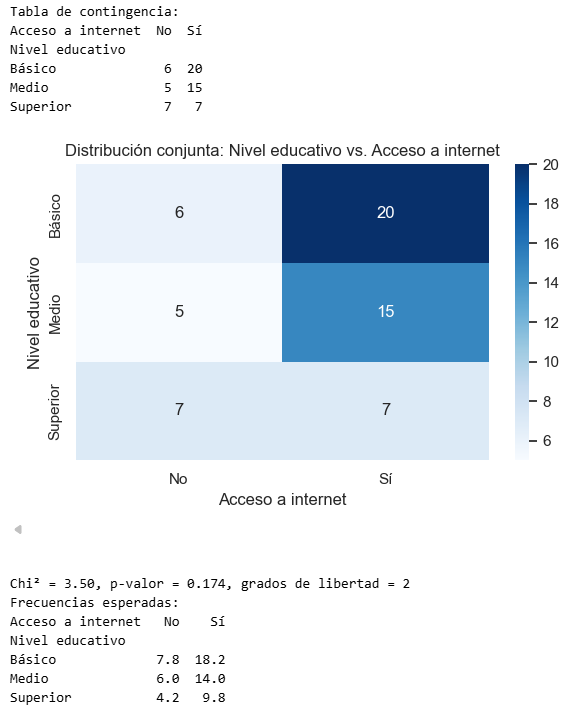

# Solución Ejercicio 6

Tabla de contingencia:
day_type      Weekday  Weekend
burnout_risk                  
High               15        5
Low               724      803
Medium            137      116 



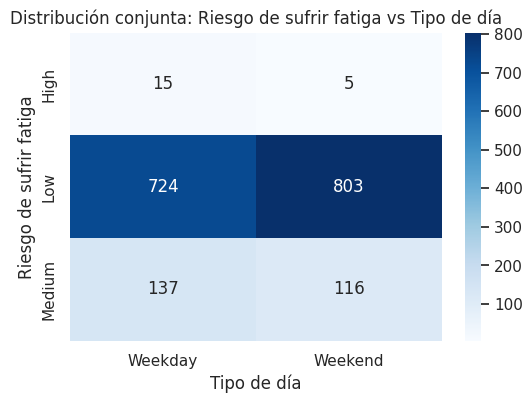


Chi² = 9.556977963877287
p-valor = 0.008408695063173805
Grados de libertad = 2

Frecuencias esperadas:
day_type         Weekday     Weekend
burnout_risk                        
High            9.733333   10.266667
Low           743.140000  783.860000
Medium        123.126667  129.873333


In [30]:
tabla = pd.crosstab(df['burnout_risk'], df['day_type'])

print("Tabla de contingencia:")
print(tabla,"\n")

chi2, p, dof, expected = chi2_contingency(tabla)

plt.figure(figsize=(6,4))
sns.heatmap(
    tabla,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Distribución conjunta: Riesgo de sufrir fatiga vs Tipo de día")
plt.xlabel("Tipo de día")
plt.ylabel("Riesgo de sufrir fatiga")
plt.show()

print("\nChi² =", chi2)
print("p-valor =", p)
print("Grados de libertad =", dof)
print("\nFrecuencias esperadas:")
print(pd.DataFrame(expected,
                   index=tabla.index,
                   columns=tabla.columns))

### Interpretación

Ya que tenemos una valor-p menor a 0.05 (0.008... < 0.05) podemos rechazar la hipótesis de independencia y afirmar que las variables están relacionadas.

# Análisis multivariado

## Regresión lineal múltiple

##Análisis de supuestos

### 1. Linealidad

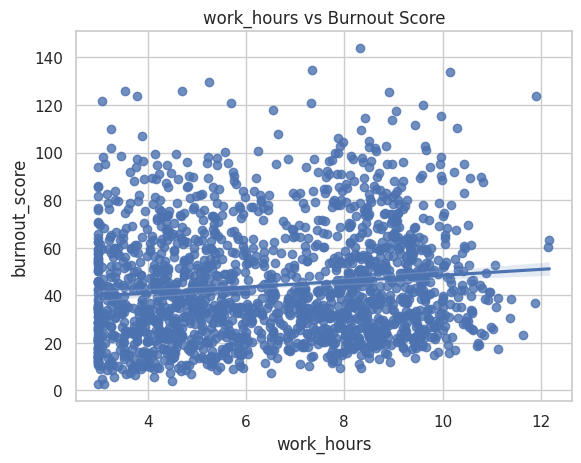

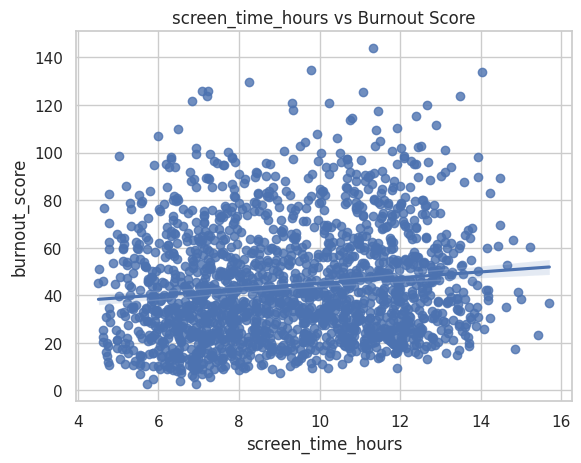

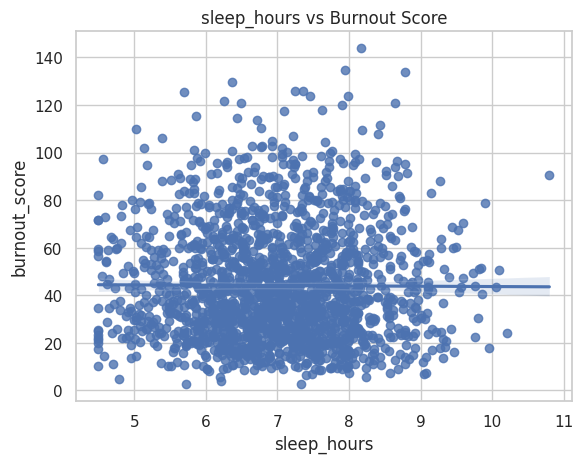

In [31]:
variables = ['work_hours', 'screen_time_hours', 'sleep_hours']

for var in variables:
    sns.regplot(x=df[var], y=df['burnout_score'])
    plt.title(f"{var} vs Burnout Score")
    plt.show()

Tiene tendencia a línea recta -> Se cumple

### 2. Independencia

In [33]:
X = df[['work_hours', 'screen_time_hours', 'sleep_hours']]
y = df['burnout_score']

X = sm.add_constant(X)
modelo = sm.OLS(y, X).fit()

print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:          burnout_score   R-squared:                       0.015
Model:                            OLS   Adj. R-squared:                  0.013
Method:                 Least Squares   F-statistic:                     9.204
Date:                Fri, 13 Mar 2026   Prob (F-statistic):           4.83e-06
Time:                        01:21:11   Log-Likelihood:                -8251.5
No. Observations:                1800   AIC:                         1.651e+04
Df Residuals:                    1796   BIC:                         1.653e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                34.3041      4.61

Durbin-Watson:                   0.714

Con este resultado no se puede afirmar que se cumpla por lo que los resultados de este análisis pueden no ser muy confiables.

### 3. Homoscedasticidad

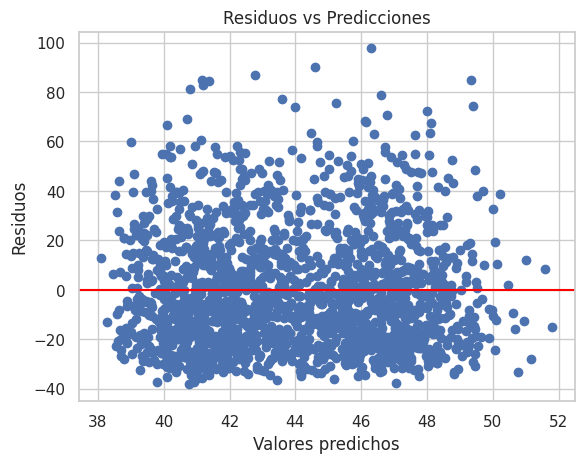

In [34]:
pred = modelo.fittedvalues
resid = modelo.resid

plt.scatter(pred, resid)
plt.axhline(0, color='red')
plt.xlabel("Valores predichos")
plt.ylabel("Residuos")
plt.title("Residuos vs Predicciones")
plt.show()

No tiene forma de embudo y se ve una distribución uniforme -> Se cumple

### 4. Normalidad

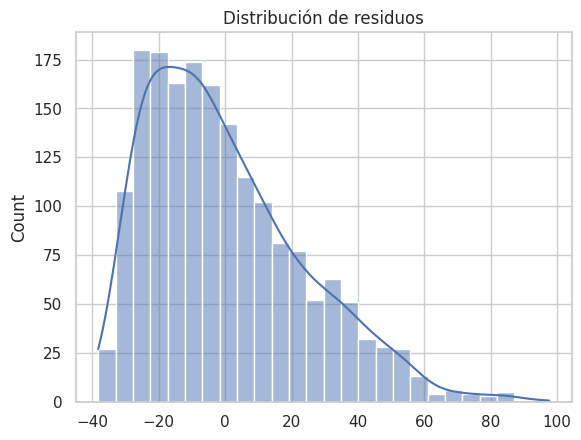

In [38]:
sns.histplot(modelo.resid, kde=True)
plt.title("Distribución de residuos")
plt.show()

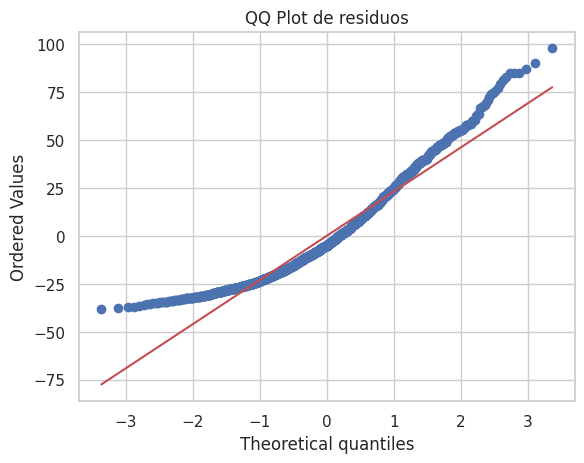

In [39]:
stats.probplot(modelo.resid, dist="norm", plot=plt)
plt.title("QQ Plot de residuos")
plt.show()

In [42]:
stat, p_value = shapiro(resid)
print(f"Prueba de Shapiro–Wilk")
print(f"Estadístico: {stat:.4f}")
print(f"p-valor: {p_value:.4f} → {'Se asume normalidad' if p_value > 0.05 else 'No se cumple el supuesto de normalidad'}")

Prueba de Shapiro–Wilk
Estadístico: 0.9402
p-valor: 0.0000 → No se cumple el supuesto de normalidad


### 5. Ausencia de multicolinealidad

In [44]:
X = df[['work_hours', 'screen_time_hours', 'sleep_hours']]
X = sm.add_constant(X)

vif = pd.DataFrame()
vif["Variable"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif)

            Variable        VIF
0              const  68.170958
1         work_hours  11.227193
2  screen_time_hours  11.225642
3        sleep_hours   1.001159


Con valores VIF elevados, identificamos multicolinealidad severa. El supuesto no se cumple

### RLM

In [46]:
X = df[['work_hours', 'screen_time_hours', 'sleep_hours']]
y = df['burnout_score']

X = sm.add_constant(X)
modelo = sm.OLS(y, X).fit()

print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:          burnout_score   R-squared:                       0.015
Model:                            OLS   Adj. R-squared:                  0.013
Method:                 Least Squares   F-statistic:                     9.204
Date:                Fri, 13 Mar 2026   Prob (F-statistic):           4.83e-06
Time:                        01:36:19   Log-Likelihood:                -8251.5
No. Observations:                1800   AIC:                         1.651e+04
Df Residuals:                    1796   BIC:                         1.653e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                34.3041      4.61

Para las variables existen los siguientes coeficientes:


*   work_hours:            0.2743
*   creen_time_hours:     0.9668
*   sleep_hours:          -0.1494

Esto nos podría decir que las variables con valores de coeficiente superiores a cero, aumetan la fatiga, y las menores a cero disminuyen la fatiga, pero ya que en el análisis de supuestos 3 de ellos no cumplen, no se puede decir que el análisis a través de este método sea válido o confiable.

